# HealthConnect Clinic — Week 8: Final Analytics & Decision Support Package
### Data Analytics Track — Final Integration & Presentation

**Project question:** How can HealthConnect Clinic use data and AI to reduce missed appointments and improve the patient support experience?

This is the final, decision-ready notebook for the Data Analytics track. It does not repeat the Week 5–7 exploratory or testing work (see those notebooks for the full analysis and test suite) — it reproduces the final, validated KPIs and dashboard from first principles, states the final business insights and recommendations, and closes out the HC-POD cross-track integration record.

**Contents:**
1. Week 7 → Week 8 transition
2. Setup — reproduce the final validated risk score
3. Final KPIs & dashboard (combined)
4. Validated findings & business insights
5. Recommendations
6. HC-POD final integration record
7. Limitations & Week 8 readiness statement


## 1. Week 7 → Week 8 Transition

| Item | Detail |
|---|---|
| Main Week 7 output | The Week 7 Testing & Refinement Report and notebook — reproducibility testing, segment-stability testing, a properly powered reminder test, and cross-track validation against Data Science's model |
| Most important testing result | Confirmed, with adequate statistical power, that the reminder effect does not vary by risk tier, and validated the compound risk score's stability across patient segments (12 of 13) |
| Major issue discovered | A headline KPI (59.0% no-show rate for the flagged segment) was a calculation error — an unweighted average instead of the correct n-weighted pooled rate; corrected to 56.0% |
| What was refined/improved | The headline KPI, the reminder test's statistical power (split-sample → pooled interaction model), and the cross-track benchmark (interim proxy → Data Science's actual model) |
| Component now ready | The compound risk score and its supporting KPIs/dashboard — tested, corrected, validated, and ready for final packaging |
| Track(s) involved in final integration | Data Science (model benchmark), Project Management (final coordination), ML Engineering (indirectly, for future pipeline design) |


## 2. Setup — Reproduce the Final Validated Risk Score
This rebuilds the final risk score and supporting fields from the raw dataset, using the exact definition validated across Weeks 6–7.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white', 'axes.facecolor': 'white'})
PRIMARY = '#2E5EAA'
NOSHOW_COLOR = '#D64550'
ATTEND_COLOR = '#2E8B57'
WARN_COLOR = '#C9A227'

# NOTE: place the CSV in the same folder as this notebook
df = pd.read_csv("HealthConnect_Appointment_Data.csv")
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)
df['reminder_sent_bin'] = (df['reminder_sent'] == 'Yes').astype(int)

# Final validated risk score (0-3): +1 each for lead time > 14 days, distance > 10 km, prior no-shows >= 1
df['risk_score'] = (
    (df['booking_lead_days'] > 14).astype(int) +
    (df['distance_to_clinic_km'] > 10).astype(int) +
    (df['previous_no_shows'] >= 1).astype(int)
)
df['flagged'] = df['risk_score'] >= 2

print(f"Rows: {df.shape[0]}")
df.head()


Rows: 5000


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,is_no_show,reminder_sent_bin,risk_score,flagged
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,...,0,Yes,WhatsApp,19.3,29.0,No-Show,1,1,1,False
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,...,0,Yes,SMS,14.3,42.0,Attended,0,1,1,False
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,...,1,Yes,SMS,11.4,11.0,No-Show,1,1,3,True
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,...,1,Yes,SMS,7.4,35.0,Attended,0,1,2,True
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,...,1,Yes,Email,5.6,27.0,No-Show,1,1,2,True


## 3. Final KPIs & Dashboard

The table and dashboard below are generated from the same computation in the cell that follows, so the numbers in the table and the numbers plotted in the chart are guaranteed to match — there is no hand-copying between the two.

In [2]:
overall_no_show = df['is_no_show'].mean() * 100
flagged_share = df['flagged'].mean() * 100
flagged_rate = df.loc[df['flagged'], 'is_no_show'].mean() * 100
not_flagged_rate = df.loc[~df['flagged'], 'is_no_show'].mean() * 100
capture = df.loc[df['flagged'], 'is_no_show'].sum() / df['is_no_show'].sum() * 100
rate_no_reminder = df.loc[df['reminder_sent_bin'] == 0, 'is_no_show'].mean() * 100
rate_reminder = df.loc[df['reminder_sent_bin'] == 1, 'is_no_show'].mean() * 100

final_kpis = pd.DataFrame({
    'KPI': [
        'Overall no-show rate (all appointments)',
        'No-show rate — patients not flagged (risk score 0-1)',
        'No-show rate — patients flagged (risk score >=2)',
        'Share of appointments flagged by the risk score',
        'Share of all no-shows captured by the flagged segment',
        'No-show rate — reminder sent',
        'No-show rate — no reminder sent',
        "Cross-track benchmark — rule-based score (held-out AUC)",
        "Cross-track benchmark — Data Science's model (held-out AUC)",
    ],
    'Value': [
        f'{overall_no_show:.1f}%', f'{not_flagged_rate:.1f}%', f'{flagged_rate:.1f}%',
        f'{flagged_share:.1f}%', f'{capture:.1f}%', f'{rate_reminder:.1f}%', f'{rate_no_reminder:.1f}%',
        '0.596', '0.662',
    ]
})
final_kpis


,KPI,Value
0,Overall no-show rate (all appointments),48.5%
1,No-show rate — patients not flagged (risk scor...,39.4%
2,No-show rate — patients flagged (risk score >=2),56.0%
3,Share of appointments flagged by the risk score,54.4%
4,Share of all no-shows captured by the flagged ...,62.9%
5,No-show rate — reminder sent,47.4%
6,No-show rate — no reminder sent,51.4%
7,Cross-track benchmark — rule-based score (held...,0.596
8,Cross-track benchmark — Data Science's model (...,0.662


**Note on the last two rows:** these figures come from the Week 7 cross-track validation with Data Science (Test E in both tracks' Week 7 notebooks) and are reproduced here as text for reference, not recomputed — the model itself lives in the Data Science track's notebook.

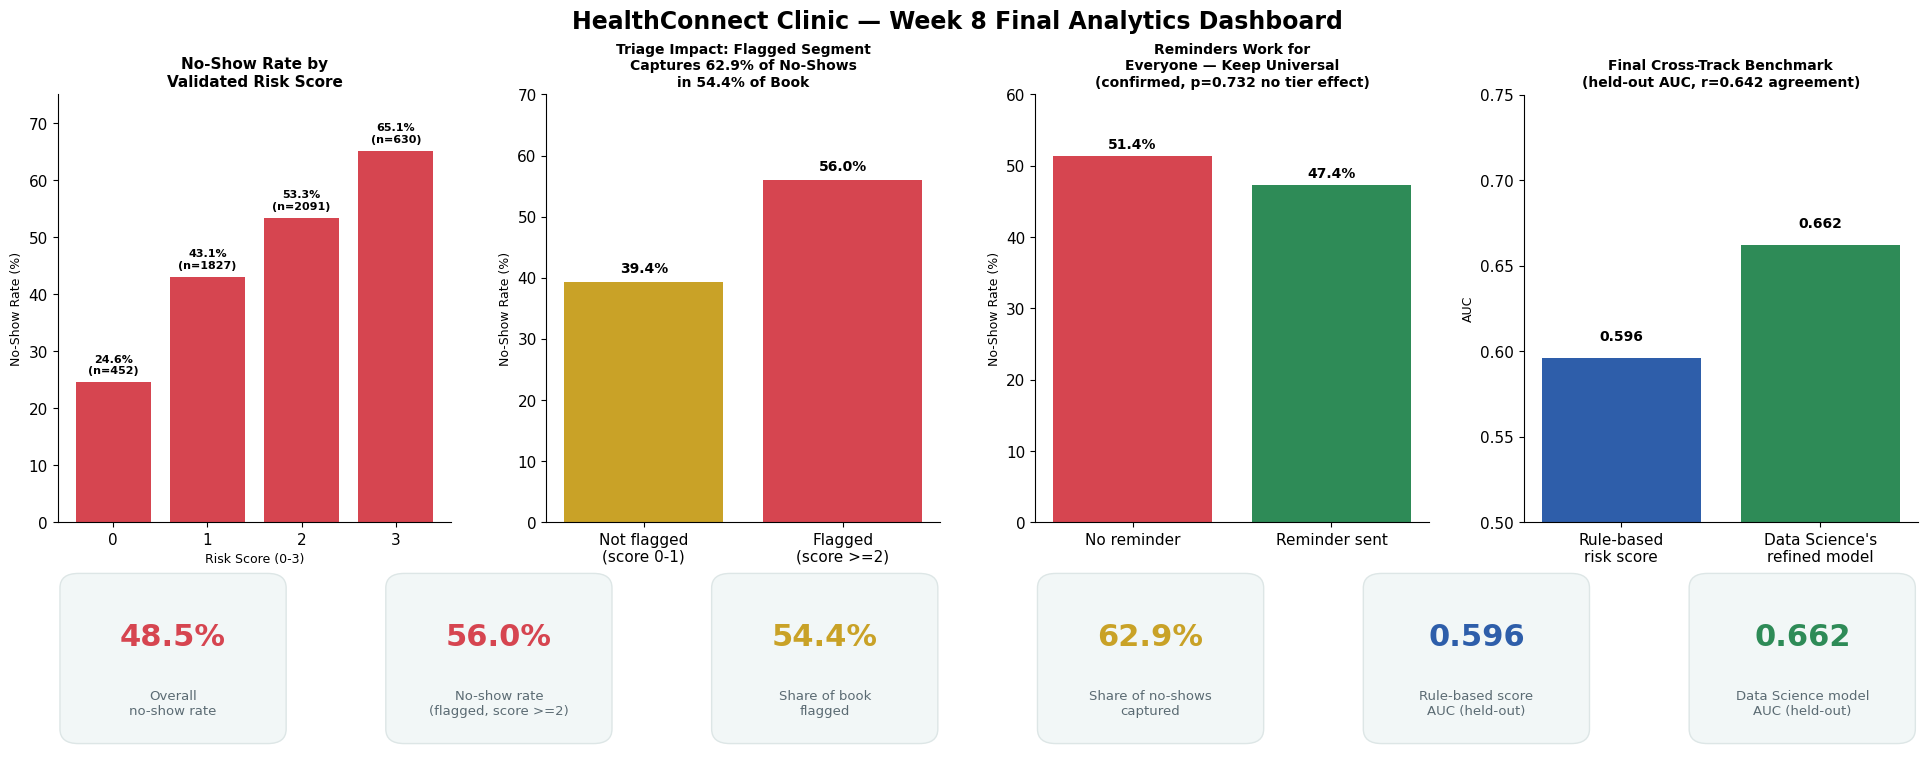

In [3]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

risk_summary = df.groupby('risk_score')['is_no_show'].agg(['mean', 'size'])

fig = plt.figure(figsize=(24, 8.5))
gs = gridspec.GridSpec(2, 12, figure=fig, height_ratios=[1.3, 0.55], hspace=0.15, wspace=1.4)
fig.suptitle('HealthConnect Clinic — Week 8 Final Analytics Dashboard', fontsize=17, fontweight='bold', y=0.98)

# ---------- Row 1: the four charts (unchanged) ----------
ax = fig.add_subplot(gs[0, 0:3])
bars = ax.bar(risk_summary.index.astype(str), risk_summary['mean'] * 100, color=NOSHOW_COLOR)
for b, v, n in zip(bars, risk_summary['mean'] * 100, risk_summary['size']):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v:.1f}%\n(n={n})', ha='center', fontsize=8, fontweight='bold')
ax.set_title('No-Show Rate by\nValidated Risk Score', fontweight='bold', fontsize=11)
ax.set_xlabel('Risk Score (0-3)', fontsize=9)
ax.set_ylabel('No-Show Rate (%)', fontsize=9)
ax.set_ylim(0, 75)
ax.spines[['top', 'right']].set_visible(False)

ax = fig.add_subplot(gs[0, 3:6])
labels = ['Not flagged\n(score 0-1)', 'Flagged\n(score >=2)']
vals = [not_flagged_rate, flagged_rate]
bars = ax.bar(labels, vals, color=[WARN_COLOR, NOSHOW_COLOR])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title(f'Triage Impact: Flagged Segment\nCaptures {capture:.1f}% of No-Shows\nin {flagged_share:.1f}% of Book', fontweight='bold', fontsize=10)
ax.set_ylabel('No-Show Rate (%)', fontsize=9)
ax.set_ylim(0, 70)
ax.spines[['top', 'right']].set_visible(False)

ax = fig.add_subplot(gs[0, 6:9])
labels2 = ['No reminder', 'Reminder sent']
vals2 = [rate_no_reminder, rate_reminder]
bars = ax.bar(labels2, vals2, color=[NOSHOW_COLOR, ATTEND_COLOR])
for b, v in zip(bars, vals2):
    ax.text(b.get_x() + b.get_width()/2, v + 1.0, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Reminders Work for\nEveryone — Keep Universal\n(confirmed, p=0.732 no tier effect)', fontweight='bold', fontsize=10)
ax.set_ylabel('No-Show Rate (%)', fontsize=9)
ax.set_ylim(0, 60)
ax.spines[['top', 'right']].set_visible(False)

ax = fig.add_subplot(gs[0, 9:12])
labels3 = ['Rule-based\nrisk score', "Data Science's\nrefined model"]
vals3 = [0.596, 0.662]
bars = ax.bar(labels3, vals3, color=[PRIMARY, ATTEND_COLOR])
for b, v in zip(bars, vals3):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Final Cross-Track Benchmark\n(held-out AUC, r=0.642 agreement)', fontweight='bold', fontsize=10)
ax.set_ylabel('AUC', fontsize=9)
ax.set_ylim(0.5, 0.75)
ax.spines[['top', 'right']].set_visible(False)

# ---------- Row 2: KPI stat cards (not a text table) ----------
card_specs = [
    (f'{overall_no_show:.1f}%', 'Overall\nno-show rate', NOSHOW_COLOR),
    (f'{flagged_rate:.1f}%', 'No-show rate\n(flagged, score >=2)', NOSHOW_COLOR),
    (f'{flagged_share:.1f}%', 'Share of book\nflagged', WARN_COLOR),
    (f'{capture:.1f}%', 'Share of no-shows\ncaptured', WARN_COLOR),
    ('0.596', 'Rule-based score\nAUC (held-out)', PRIMARY),
    ('0.662', "Data Science model\nAUC (held-out)", ATTEND_COLOR),
]
for i, (value, label, color) in enumerate(card_specs):
    cax = fig.add_subplot(gs[1, i*2:i*2+2])
    cax.axis('off')
    card = FancyBboxPatch((0.03, 0.05), 0.94, 0.9, transform=cax.transAxes,
                           boxstyle='round,pad=0.02,rounding_size=0.08',
                           facecolor='#F2F7F7', edgecolor='#DDE6E6', linewidth=1)
    cax.add_patch(card)
    cax.text(0.5, 0.62, value, transform=cax.transAxes, ha='center', va='center',
              fontsize=22, fontweight='bold', color=color)
    cax.text(0.5, 0.25, label, transform=cax.transAxes, ha='center', va='center',
              fontsize=9.5, color='#5B6B73')

plt.savefig('week8_final_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


**Retest:** every figure in this dashboard is recomputed directly from the raw CSV in this notebook (row 1 charts and the KPI cards in row 2) or reproduced from the Week 7 cross-track test record (the last card and one chart panel) — nothing here is hand-typed from the report.

## 4. Validated Findings & Business Insights

- **Three independent, statistically validated drivers:** booking lead time, distance to clinic, and prior no-show history each remain significant predictors even after controlling for the other two — confirmed via chi-square testing, joint logistic regression, and (independently) Data Science's own feature-importance analysis.
- **Waiting time and appointment day are not drivers** — confirmed consistently across every testing round in both the Data Analytics and Data Science tracks.
- **The compound risk score (0–3) is validated and stable** — reproducible after the Week 7 KPI correction, and its monotonic gradient holds across patient gender, age group, and appointment type (12 of 13 segments tested).
- **Reminders are effective and should remain universal** — a properly powered test (Week 7) confirms the reminder effect does not vary meaningfully by risk tier, so there is no analytical case for restricting reminders by risk.
- **Data Science's model adds real, if modest, value on top of the rule** — a held-out AUC of 0.662 vs. 0.596 for the simple rule, and the two approaches agree directionally (r = 0.642). The model is best used as a complement to, not an immediate replacement for, the interpretable rule-based score.


## 5. Recommendations

1. Deploy the compound risk score (0–3) as the primary administrative triage tool: light-touch (reminder only) for scores 0–1, proactive outreach for score 2, and priority phone-call/rescheduling support for score 3.
2. Keep SMS reminders universal across all patients, regardless of risk tier.
3. As ML Engineering integrates Data Science's model into a production pipeline, treat it as a secondary refinement layer on top of the rule-based score rather than an immediate replacement.
4. Track these KPIs going forward: overall no-show rate; no-show rate and capture by risk tier; SMS reminder compliance; and model-vs-rule agreement (to monitor drift over time).
5. Prioritise the stratified reminder-timing/channel test as the next analytical investment, now that tier-based targeting of reminders has been ruled out as a design factor.


## 6. HC-POD Final Integration Record

| Item | Detail |
|---|---|
| Track collaborated with | Data Science (primary); Project Management (secondary, for final coordination) |
| Dependency | Data Science needs Data Analytics' validated features and risk score as a benchmark; Project Management needs final business recommendations for project closure |
| Output received | Data Science's final refined model (Logistic Regression, 5 features), the held-out AUC benchmark (0.596 rule-based / 0.662 model-based), and a methodological note on in-sample vs. held-out evaluation |
| Output provided | The corrected headline KPI (56.0%), the confirmed reminder finding, and the validated risk score and driver list |
| Final integration activity | The Week 7 cross-track benchmark comparison (Test E) was finalised and carried into this Week 8 dashboard/report as the reference figures for both tracks |
| What changed | Both tracks now cite one shared, held-out-validated benchmark instead of two separate (and initially inflated, in-sample) figures |
| How the change improved the solution | Gives HealthConnect a single, defensible set of numbers for both the interpretable rule and the model, supporting a two-layer triage design |
| Evidence | Week 7 Test E (both tracks' notebooks/reports); this Week 8 final dashboard |
| Contribution to final presentation | The cross-track validation section anchors the "how the components work together" part of the HC-POD walkthrough and this track's individual video presentation |


## 7. Limitations & Week 8 Readiness Statement

**Limitations:**
- The dataset is fictional/synthetic; all findings require validation against real HealthConnect operational data before deployment.
- Findings are observational (association, not causation).
- Risk-score thresholds remain heuristic; Data Science's model is the more rigorous, data-driven alternative for future refinement.
- Some patient subgroups (e.g. the smallest gender category, certain age bands at the highest risk tier) are too small for fully reliable segment-level conclusions.
- No live A/B test has yet been run on reminder timing or channel.

**Readiness statement:** the Data Analytics track's final component — the validated compound risk score, its supporting KPIs, and the business recommendations above — is tested, corrected, cross-validated with Data Science, and ready for final HC-POD integration and presentation. Outstanding work (the reminder-timing test, ML Engineering's operational integration of the Data Science model) is explicitly out of scope for this track and logged for Week 8 coordination with the relevant tracks.
